# ReBayesed EDA

First look at the data - let's see what we can find...

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import plotly.express as px
import plotly.io as pio
import rdata

DATA_FILE = Path("data/Individual_Studies/filtered-network-data-2026-09-21.rds")

# the kernel starts in src/eda/, so walk up until the data shows up
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / DATA_FILE).exists())
DATA = ROOT / DATA_FILE
FIGURES = ROOT / "reports/figures"

TEMPLATE = "plotly_dark"
BLUE = "#3987e5"
GREY = "#898781"

# ordered from "edge is absent" to "edge is present". red = against, blue = for,
# grey = can't tell
EVIDENCE_ORDER = ["excluded", "weak excluded", "inconclusive", "weak included", "included"]
EVIDENCE_COLORS = {
    "excluded": "#d03b3b",
    "weak excluded": "#e66767",
    "inconclusive": GREY,
    "weak included": "#86b6ef",
    "included": BLUE,
}

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 50)

pio.renderers.default = "plotly_mimetype+png"
pio.renderers["png"].scale = 2


def show(fig, name):
    """draw the figure, and keep a PNG around because the report will want it."""
    FIGURES.mkdir(parents=True, exist_ok=True)
    fig.write_image(
        FIGURES / f"{name}.png",
        width=1000,
        height=fig.layout.height or 500,
        scale=2,
    )
    fig.show()

In [2]:
networks = rdata.read_rds(str(DATA))
print(f"{len(networks)} networks")
print("keys on one network:", list(networks[list(networks)[0]]))

294 networks
keys on one network: [np.str_('p'), np.str_('n_edges'), np.str_('meta'), np.str_('modSelect_parameters'), np.str_('modSelect_n_inc'), np.str_('modSelect_n_exc'), np.str_('EBIC_parameters'), np.str_('EBIC_n_inc'), np.str_('EBIC_n_exc'), np.str_('BGGM_parameters'), np.str_('BGGM_inc_probs'), np.str_('BGGM_BF'), np.str_('BGGM_category'), np.str_('BGGM_color'), np.str_('BGGM2_parameters'), np.str_('BGGM2_inc_probs'), np.str_('BGGM2_BF'), np.str_('BGGM2_category'), np.str_('BGGM2_color'), np.str_('BGGM3_parameters'), np.str_('BGGM3_inc_probs'), np.str_('BGGM3_BF'), np.str_('BGGM3_category'), np.str_('BGGM3_color')]


So: 294 networks, each one a little bundle of `p`, `n_edges`, a `meta` block, and then
edge estimates from five different fits - two frequentist (`EBIC_*`, `modSelect_*`) and
three Bayesian (`BGGM_*`, `BGGM2_*`, `BGGM3_*`). Three Bayesian ones is a bit odd...

## Converting to Pandas

Everything is nested a couple of levels deep.
Forgot that R has no scalars, so a single number comes back
as an array, and the node names appear twice - once as the `variable_names` string in
the metadata and once as the dimnames of the correlation matrix. Need to check that they are the same...

In [3]:
def scalar(value):
    """R has no scalars, so single numbers come back as length-one arrays."""
    if isinstance(value, np.ndarray):
        return value.flat[0] if value.size else None
    return value


def node_labels(entry):
    """node names, taken off the correlation matrix."""
    matrix = entry["meta"]["correlation_matrix"]
    return [str(v) for v in matrix.coords[list(matrix.coords)[0]].values]


def metadata_labels(entry):
    """node names, taken off the `variable_names` string instead."""
    raw = str(scalar(entry["meta"]["variable_names"]))
    return [name.strip() for name in raw.split(";") if name.strip()]


records = []
for nid, entry in networks.items():
    meta = entry["meta"]
    corr = np.asarray(meta["correlation_matrix"], dtype=float)
    p = int(scalar(entry["p"]))
    n = int(scalar(meta["sample_size"]))
    possible_edges = p * (p - 1) // 2
    records.append(dict(
        network_id=str(nid),
        paper_id=str(scalar(meta["paperID"])),
        year=int(float(scalar(meta["year"]))) if scalar(meta["year"]) is not None else None,
        nodes=p,
        sample_size=n,
        possible_edges=possible_edges,
        obs_per_edge=n / possible_edges,
        model=str(scalar(meta["model"])),
        subtype=str(scalar(meta["network_subtype"])),
        topic=str(scalar(meta["topic"])),
        subtopic=str(scalar(meta["subtopic"])),
        var_type=str(scalar(meta["type_of_variables"])),
        sample_type=str(scalar(meta["sample_type"])),
        min_eigenvalue=float(np.linalg.eigvalsh(corr).min()),
        has_modselect="modSelect_parameters" in entry,
    ))

nets = pd.DataFrame(records)

agreement = pd.Series([
    "same, in order" if metadata_labels(e) == node_labels(e)
    else "same, reordered" if sorted(metadata_labels(e)) == sorted(node_labels(e))
    else "different labels"
    for e in networks.values()
]).value_counts()

print("variable_names against correlation matrix dimnames:")
print(agreement.to_string())
print(nets.shape)
nets.head()

variable_names against correlation matrix dimnames:
different labels    233
same, reordered      35
same, in order       26
(294, 15)


,network_id,paper_id,year,nodes,sample_size,possible_edges,obs_per_edge,model,subtype,topic,subtopic,var_type,sample_type,min_eigenvalue,has_modselect
0,N0025_1,N0025,2021,15,241,105,2.295238,GGM,original,Clinical,Rumination; Prospective Positivity; Depression,mixed,Population,0.181791,True
1,N0025_2,N0025,2021,20,241,190,1.268421,GGM,Different variables,Clinical,Rumination; Prospective Positivity; Depression,mixed,Population,0.188879,True
2,N0029_1,N0029,2022,21,696,210,3.314286,GGM,original,Clinical,Life Satisfaction; Posttraumatic Growth; Resil...,mixed,Clinical,0.148581,True
3,N0029_2,N0029,2022,10,696,45,15.466667,GGM,Subset of variables,Clinical,Life Satisfaction; Posttraumatic Growth; Resil...,mixed,Clinical,0.196603,True
4,N0029_3,N0029,2022,10,696,45,15.466667,GGM,Subset of variables,Clinical,Life Satisfaction; Posttraumatic Growth; Resil...,mixed,Clinical,0.164445,True


NOPE, they don't agree - 233 of 294 have genuinely different labels.

Going to have to use the dimnames...

## 294 networks but only 126 papers

Which means the rows aren't independent studies. (Mentioned in the rebayesed project page as well)
Let's see how many networks per paper.

126 papers, 294 networks, mean 2.3 networks per paper
58 papers report more than one network, holding 77% of all networks

network subtype:
subtype
original                                126
Different sample                         55
Different variables                      39
Subset of sample                         28
Subset of variables                      20
Different time point                     16
Different sample and different items      7
Different model                           3


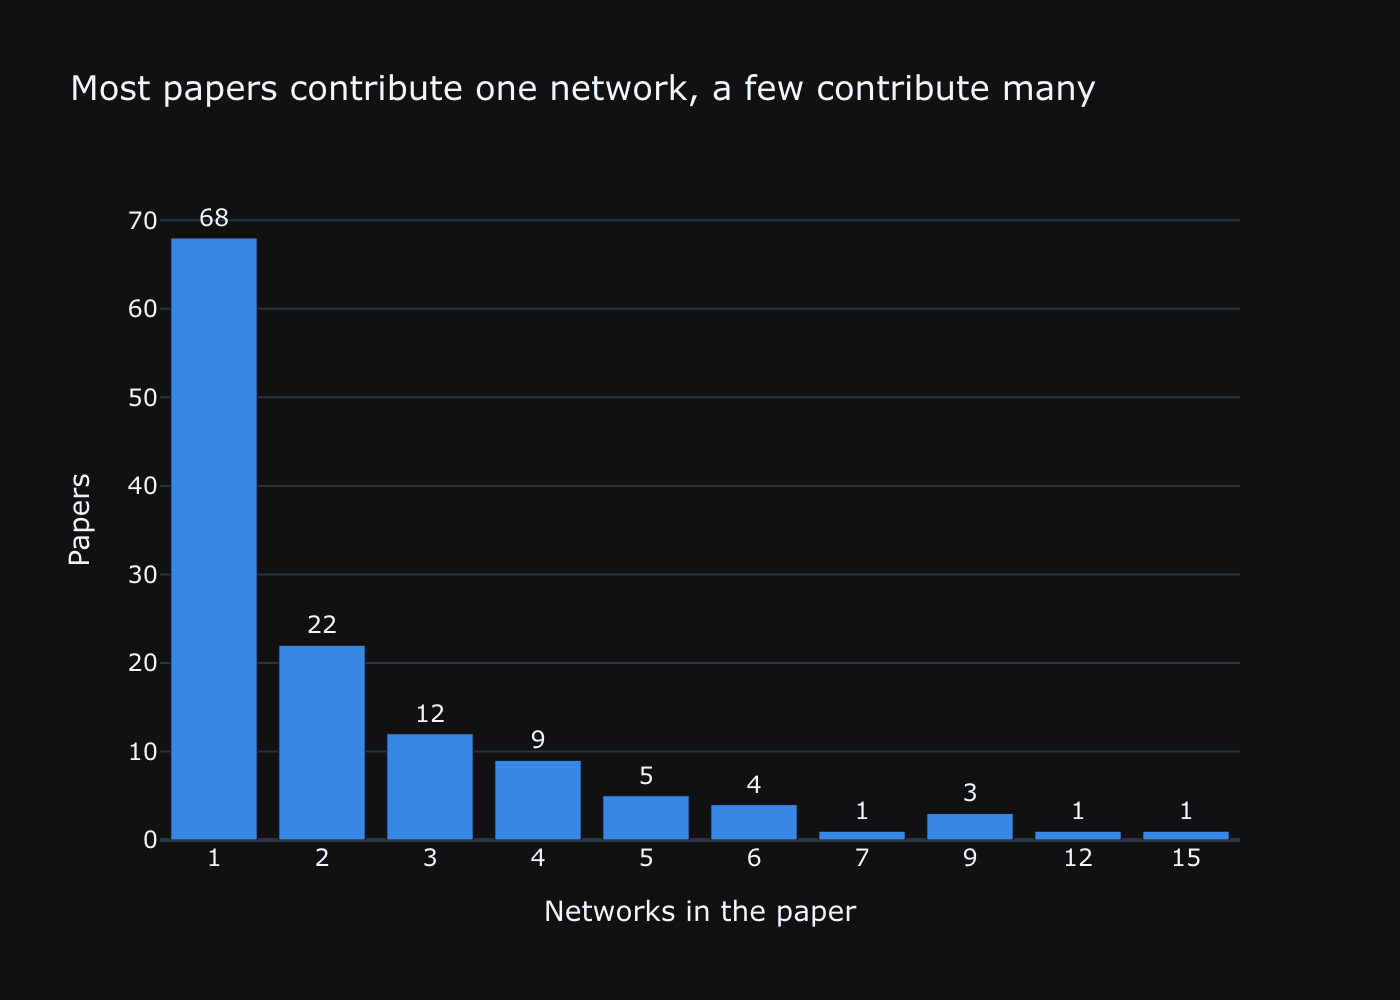

In [4]:
papers = nets.paper_id.nunique()
networks_per_paper = nets.groupby("paper_id").size()
print(f"{papers} papers, {len(nets)} networks, "
      f"mean {len(nets) / papers:.1f} networks per paper")
print(f"{(networks_per_paper > 1).sum()} papers report more than one network, holding "
      f"{(networks_per_paper > 1).reindex(nets.paper_id).mean():.0%} of all networks")
print("\nnetwork subtype:")
print(nets.subtype.value_counts().to_string())

counts = networks_per_paper.value_counts().sort_index()

fig = px.bar(
    x=counts.index.astype(str),
    y=counts.values,
    template=TEMPLATE,
    title="Most papers contribute one network, a few contribute many",
    labels={"x": "Networks in the paper", "y": "Papers"},
    text=counts.values,
)
fig.update_traces(marker_color=BLUE, textposition="outside")
show(fig, "networks_per_paper")

Skewed right, was expecting that tbh. 58 papers report more than one network and between them they hold 77%
of all the rows, so anything I average over networks is really an average weighted
toward whoever published the most.

The `subtype` column turns out to be useful, though. Exactly 126 networks say
`original` - one per paper - and the rest say things like `Different sample`, `Subset
of sample`, `Different time point`. So they're essentially refits of the same study (?)

## What is all this measuring?

variable types:
 var_type
ordinal       196
continuous     71
mixed          27

sample types:
 sample_type
Population    250
Clinical       38
Mixed           6

10 most common subtopics:
subtopic
depression               32
executive functions      19
anti-roma bias           15
ptsd                     13
big five                 13
cognitive development    12
resilience               11
anxiety                   9
aesthetic effects         9
coping                    9

research topics:
 topic
Clinical                    147
Other                        50
Personality                  49
Social                       31
Public Health                 5
Diagnostics                   5
Education                     5
Work- and Organizational      2


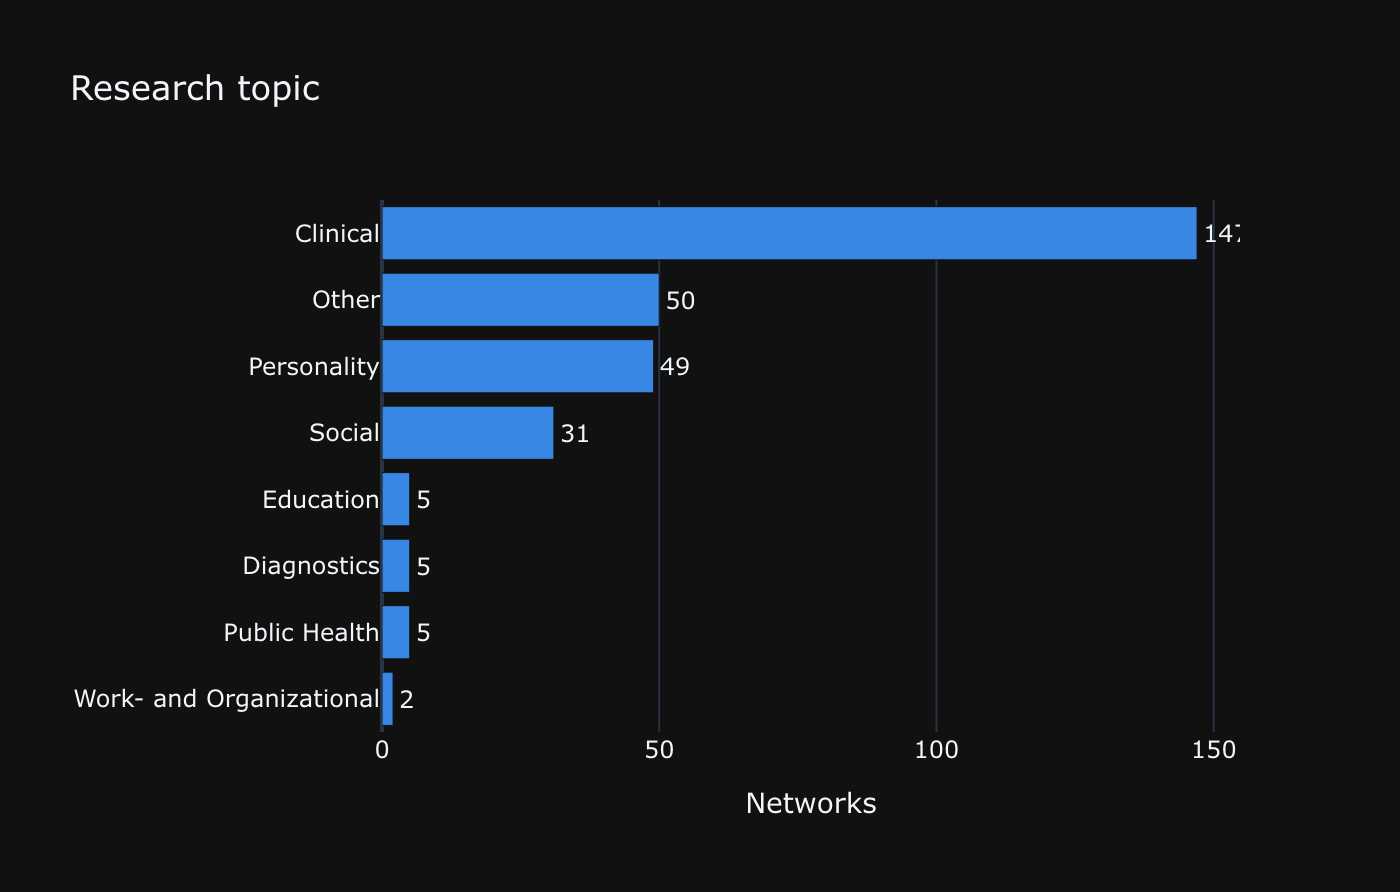

In [5]:
print("variable types:\n", nets.var_type.value_counts().to_string())
print("\nsample types:\n", nets.sample_type.value_counts().to_string())

# subtopics come as semicolon-separated lists, split before counting
subtopic_items = nets.subtopic.dropna().str.split(";").explode().str.strip().str.lower()
print("\n10 most common subtopics:")
print(subtopic_items[subtopic_items.str.len() > 0].value_counts().head(10).to_string())

topics = nets.topic.value_counts()
print("\nresearch topics:\n", topics.to_string())

fig = px.bar(
    x=topics.values,
    y=topics.index,
    orientation="h",
    template=TEMPLATE,
    title="Research topic",
    labels={"x": "Networks", "y": ""},
    text=topics.values,
)
fig.update_traces(marker_color=BLUE, textposition="outside")
fig.update_layout(
    yaxis=dict(categoryorder="total ascending"),
    height=110 + 42 * len(topics),
)
show(fig, "topic")

Two thirds of it (196 of 294) is `ordinal`.

Half is clinical (147) and depression on its own is 32 networks. And almost all the samples are general
population (250) rather than diagnosed patients.

## How much data is there per thing being estimated?

A network with `p` nodes has `p(p-1)/2` possible edges, so the number of parameters
grows quadratically while sample sizes don't. Going to try and visualize "graph complexity".

        nodes  sample_size  possible_edges  obs_per_edge
count  294.00       294.00          294.00        294.00
mean    17.70      2188.44          229.77         45.62
std     12.83     22645.24          419.70        413.16
min      3.00        23.00            3.00          0.10
25%      9.00       266.50           36.00          1.53
50%     14.00       467.50           91.00          4.97
75%     23.00       917.75          253.00         15.43
max     86.00    388286.00         3655.00       7059.75

networks below 5 observations per edge parameter: 147, below 1: 44

the one network with by far the most data per parameter:
network_id          N0648_1
nodes                    11
sample_size          388286
obs_per_edge    7059.745455


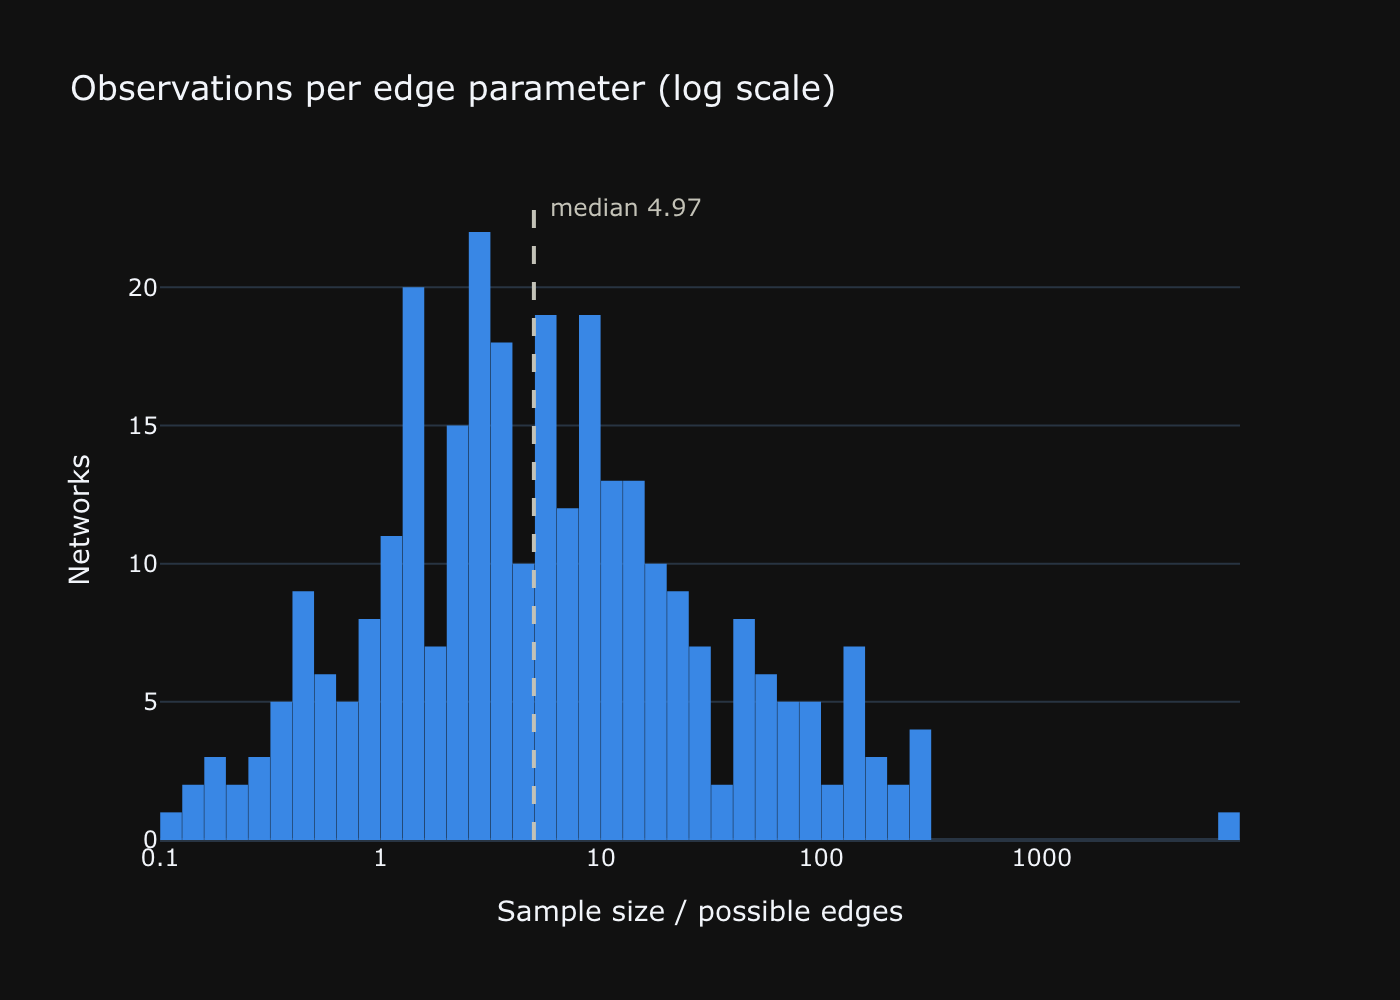

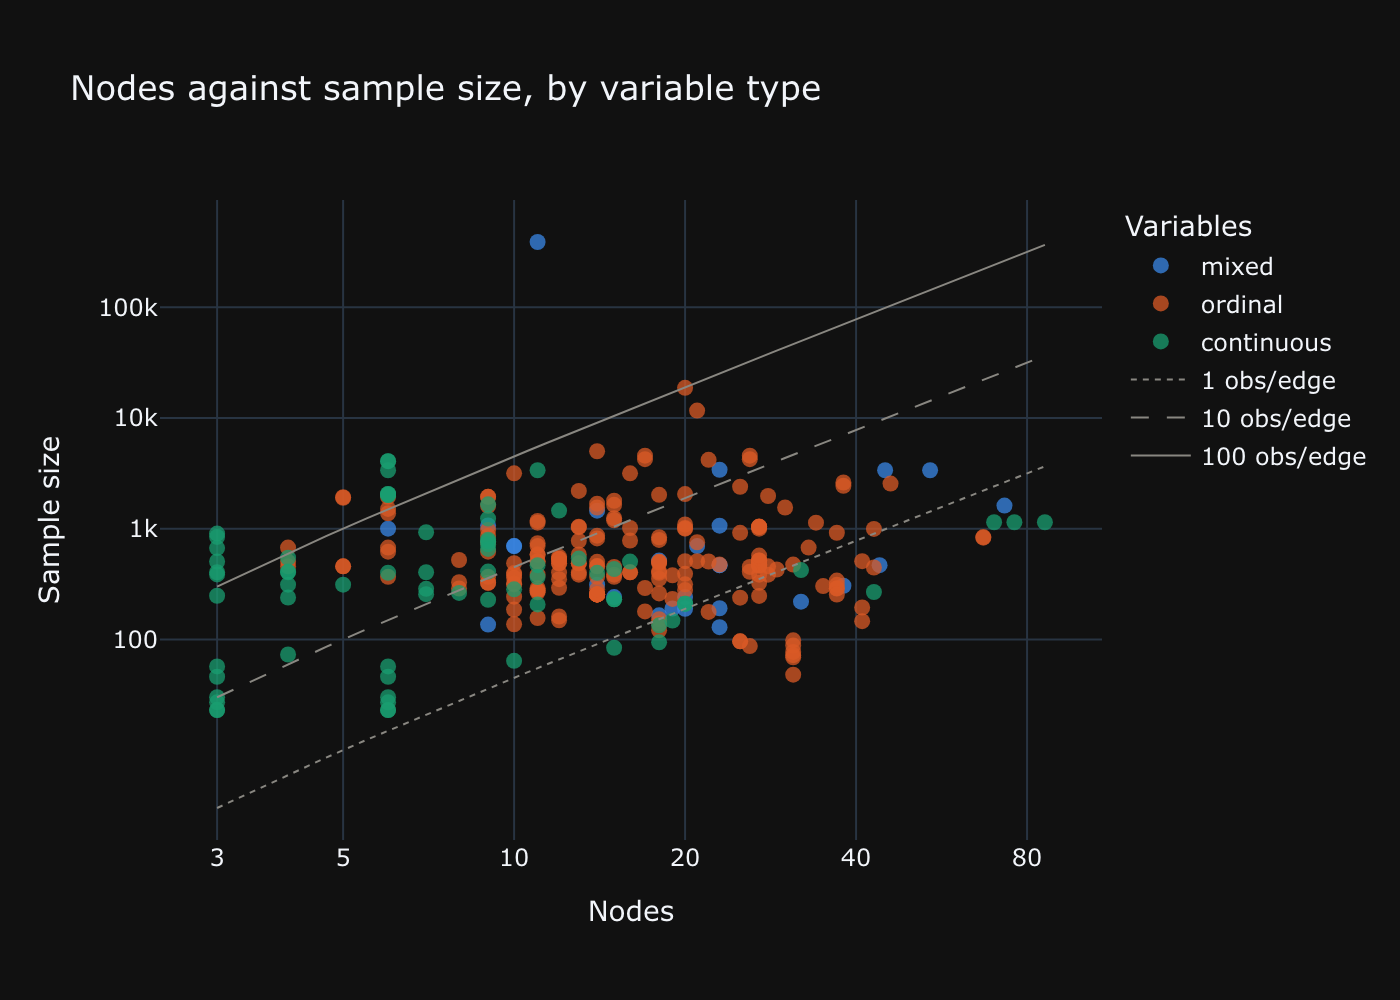

In [6]:
print(nets[["nodes", "sample_size", "possible_edges", "obs_per_edge"]].describe().round(2))

# 5 per parameter is a rule of thumb, not something from the paper
print(
    f"\nnetworks below 5 observations per edge parameter: {(nets.obs_per_edge < 5).sum()}, "
    f"below 1: {(nets.obs_per_edge < 1).sum()}"
)
print("\nthe one network with by far the most data per parameter:")
print(
    nets.loc[
        nets.obs_per_edge.idxmax(),
        ["network_id", "nodes", "sample_size", "obs_per_edge"],
    ].to_string()
)

# plotly's log_x histogram exports a blank panel through kaleido, so bin the log by
# hand and relabel the axis back into the original units
fig = px.histogram(
    x=np.log10(nets.obs_per_edge),
    nbins=60,
    template=TEMPLATE,
    title="Observations per edge parameter (log scale)",
    labels={"x": "Sample size / possible edges"},
)
fig.update_traces(marker_color=BLUE, marker_line_width=0)
fig.update_xaxes(
    tickvals=[-1, 0, 1, 2, 3],
    ticktext=["0.1", "1", "10", "100", "1000"],
)
fig.update_yaxes(title="Networks")
fig.update_layout(bargap=0.02)
fig.add_vline(x=np.log10(nets.obs_per_edge.median()), line_dash="dash", line_color="#c3c2b7")

# its own annotation - on the vline itself the text sits flush against the dash and
# reads as part of the word
fig.add_annotation(
    x=np.log10(nets.obs_per_edge.median()),
    y=1.02,
    yref="paper",
    text=f"median {nets.obs_per_edge.median():.2f}",
    showarrow=False,
    xanchor="left",
    xshift=6,
    font=dict(color="#c3c2b7"),
)
show(fig, "obs_per_edge")

fig = px.scatter(
    nets,
    x="nodes",
    y="sample_size",
    color="var_type",
    log_x=True,
    log_y=True,
    template=TEMPLATE,
    opacity=0.75,
    hover_data=["network_id", "obs_per_edge", "topic"],
    title="Nodes against sample size, by variable type",
    labels={"nodes": "Nodes", "sample_size": "Sample size", "var_type": "Variables"},
    color_discrete_sequence=["#3987e5", "#d95926", "#199e70"],
)

# a different dash per curve, otherwise the legend is three identical grey lines
grid = np.linspace(nets.nodes.min(), nets.nodes.max(), 100)
for ratio, label, dash in [
    (1, "1 obs/edge", "dot"),
    (10, "10 obs/edge", "dash"),
    (100, "100 obs/edge", "solid"),
]:
    fig.add_scatter(
        x=grid,
        y=ratio * grid * (grid - 1) / 2,
        mode="lines",
        line=dict(color=GREY, width=1, dash=dash),
        name=label,
        hoverinfo="skip",
    )
fig.update_traces(marker=dict(size=8), selector=dict(mode="markers"))

# plotly labels every minor tick on a log axis, which prints bare mantissas
# ("3 4 5 ... 10 2 3 4") and reads as nonsense. decades only
fig.update_xaxes(tickvals=[3, 5, 10, 20, 40, 80], ticktext=["3", "5", "10", "20", "40", "80"])
fig.update_yaxes(tickvals=[100, 1_000, 10_000, 100_000], ticktext=["100", "1k", "10k", "100k"])
show(fig, "nodes_vs_sample")

That's worse than I expected tbh. The median network has 14 nodes - so 91 edge parameters - fitted on 467 people, which is about 5 observations per parameter. 147 of the 294 sit below 5 and 44 have fewer people than parameters

## The single edges

Three Bayesian fits and I have to pick one. `BGGM_*` looks like the main one and the numbered ones like extras, but the field doc gives their prior s.d. as `sqrt(1/8)`, `sqrt(1/24)` and `sqrt(1/16)`. The paper sets its prior std. dev. to "the default value of 0.25", and then says it varied the std. dev. over `sqrt(1/8)`, `sqrt(1/16)` and `sqrt(1/24)` as a robustness check

In [7]:
for name, denominator in [("BGGM", 8), ("BGGM2", 24), ("BGGM3", 16)]:
    print(f"{name}_* prior sd = sqrt(1/{denominator}) = {np.sqrt(1 / denominator):.3f}")

BGGM_* prior sd = sqrt(1/8) = 0.354
BGGM2_* prior sd = sqrt(1/24) = 0.204
BGGM3_* prior sd = sqrt(1/16) = 0.250


`BGGM3_*` would be the main analysis then!

Anywho, every fit stores its numbers as a square matrix, same shape as a correlation matrix (good ol pd.corr, been a minute old friend) - variables down the side, the same variables across the top, mirrored, and a diagonal that's just a variable against itself. So the edges of one network are the upper triangle minus the diagonal.

That gives me a small table per network, 105 rows for a 15 node network, one row per pair. `pd.concat` those 294 tables into one long one and every possible edge in the corpus sits in a single table, with a `network_id` column saying where each row came from. Then "how many edges are inconclusive" is one line instead of poking at 294 separate matrices.

In [8]:
def upper_triangle(entry, key, p):
    """top half of one network's grid, as a flat list of edges."""
    rows, cols = np.triu_indices(p, k=1)
    if key not in entry:
        return np.full(len(rows), np.nan)   # not every network has every fit
    values = np.asarray(entry[key])
    if values.ndim == 1:
        # this one came out as one long line instead of a square, so fold it back. R
        # fills columns first and numpy fills rows first, so it lands transposed, which
        # doesn't matter here because the grids are mirrored anyway
        values = values.reshape(p, p)
    return values[rows, cols]


def edge_frame(nid, entry):
    """one row per possible edge of one network."""
    p = int(scalar(entry["p"]))
    labels = node_labels(entry)
    rows, cols = np.triu_indices(p, k=1)
    return pd.DataFrame({
        "network_id": nid,
        "node_a": [labels[i] for i in rows],
        "node_b": [labels[j] for j in cols],
        "partial_cor": upper_triangle(entry, "BGGM3_parameters", p),
        "inclusion_bf": upper_triangle(entry, "BGGM3_BF", p),
        "evidence": upper_triangle(entry, "BGGM3_category", p),
        "ebic_estimate": upper_triangle(entry, "EBIC_parameters", p),
        "modselect_estimate": upper_triangle(entry, "modSelect_parameters", p),
        # the other two priors, to compare against in a minute
        "evidence_prior_wide": upper_triangle(entry, "BGGM_category", p),
        "evidence_prior_narrow": upper_triangle(entry, "BGGM2_category", p),
    })


edges = pd.concat(
    [edge_frame(str(nid), entry) for nid, entry in networks.items()],
    ignore_index=True,
)
edges = edges.merge(
    nets[["network_id", "nodes", "sample_size", "obs_per_edge", "topic"]],
    on="network_id",
)
edges["evidence"] = pd.Categorical(edges.evidence, categories=EVIDENCE_ORDER, ordered=True)
print(f"{len(edges):,} possible edges across {edges.network_id.nunique()} networks")
edges.head()

67,552 possible edges across 294 networks


,network_id,node_a,node_b,partial_cor,inclusion_bf,evidence,ebic_estimate,modselect_estimate,evidence_prior_wide,evidence_prior_narrow,nodes,sample_size,obs_per_edge,topic
0,N0025_1,phys,concen,0.162620,4.332151,weak included,0.093246,0.172547,weak included,weak included,15,241,2.295238,Clinical
1,N0025_1,phys,deserve,-0.089773,0.568619,inconclusive,0.000000,0.000000,inconclusive,inconclusive,15,241,2.295238,Clinical
2,N0025_1,phys,alone,0.157455,3.861517,weak included,0.108732,0.168094,inconclusive,weak included,15,241,2.295238,Clinical
3,N0025_1,phys,write,-0.047922,0.306063,weak excluded,0.000000,0.000000,weak excluded,inconclusive,15,241,2.295238,Clinical
4,N0025_1,phys,handle,-0.049398,0.311861,weak excluded,0.000000,0.000000,weak excluded,inconclusive,15,241,2.295238,Clinical


67,552 rows, which is `p(p-1)/2` summed over all 294 networks, so nothing went missing on the way.

## How much evidence is actually behind an edge?

The categories are Jeffreys bands on the inclusion Bayes factor, cut at 1/10, 1/3, 3 and 10. So "included" means the data is at least 10x more likely with that edge than without it, and "inconclusive" means it can't tell either way.

evidence
excluded          5.5
weak excluded    46.2
inconclusive     31.3
weak included     4.3
included         12.7

inconclusive share, other priors:
  BGGM  sqrt(1/8)  22.6
  BGGM2 sqrt(1/24) 37.5


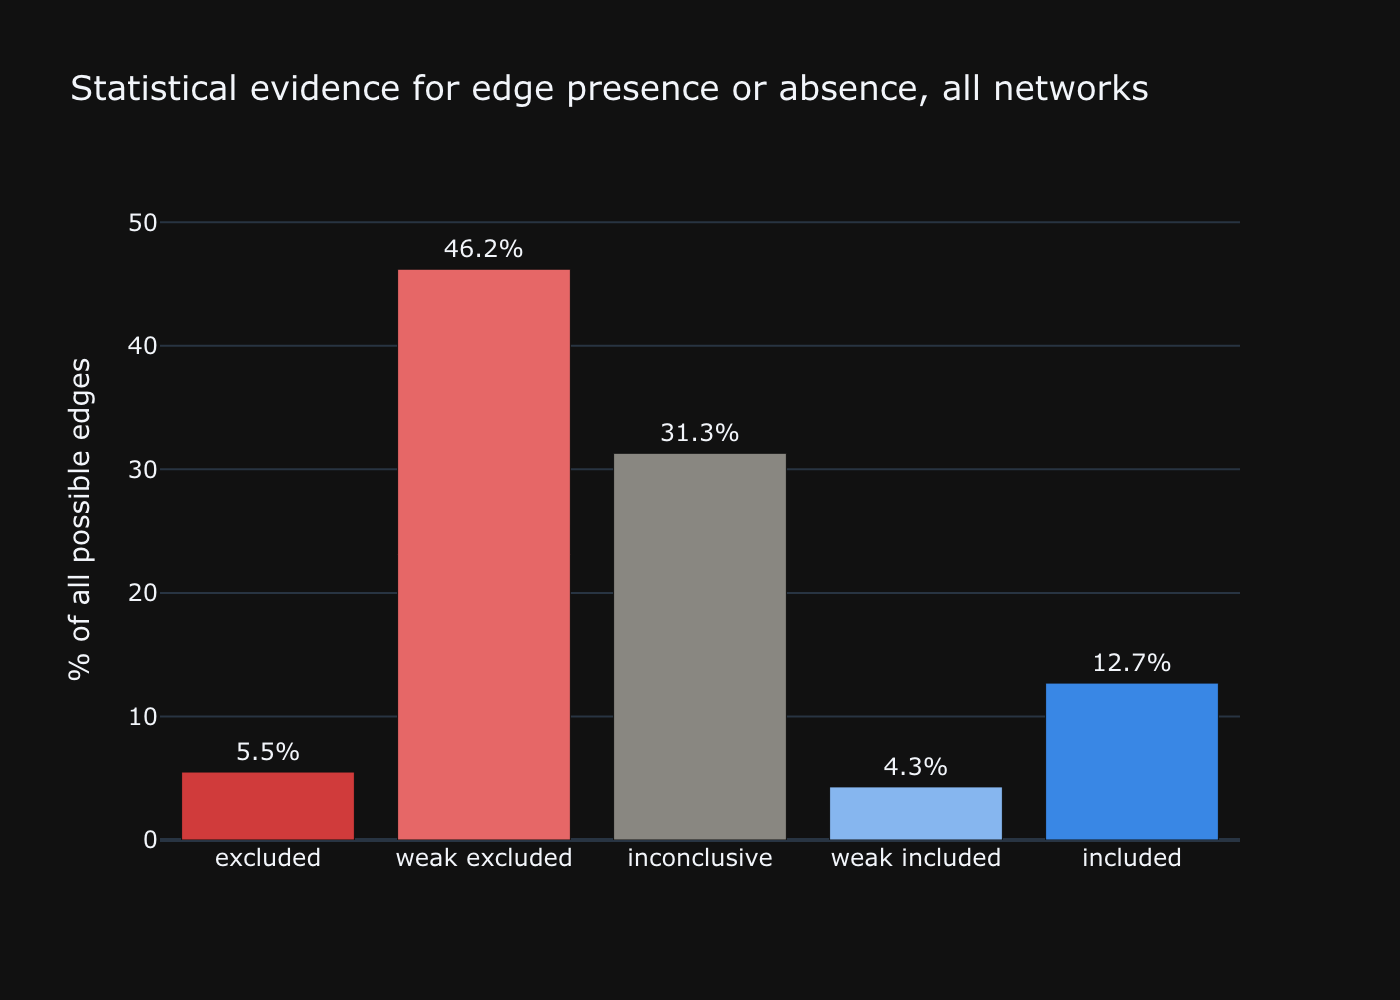

In [9]:
def evidence_share(column):
    """% of edges in each evidence category."""
    return (column.value_counts(normalize=True).reindex(EVIDENCE_ORDER) * 100).round(1)


overall = evidence_share(edges.evidence)
print(overall.to_string())

# same number under the two other priors, to see how much the choice mattered
print("\ninconclusive share, other priors:")
print(f"  BGGM  sqrt(1/8)  {evidence_share(edges.evidence_prior_wide)['inconclusive']}")
print(f"  BGGM2 sqrt(1/24) {evidence_share(edges.evidence_prior_narrow)['inconclusive']}")

fig = px.bar(
    x=overall.index,
    y=overall.values,
    template=TEMPLATE,
    color=overall.index,
    color_discrete_map=EVIDENCE_COLORS,
    title="Statistical evidence for edge presence or absence, all networks",
    labels={"x": "", "y": "% of all possible edges"},
    text=[f"{v}%" for v in overall.values],
)
fig.update_traces(textposition="outside")
fig.update_layout(showlegend=False)
show(fig, "evidence_overall")

The paper mentioned 31.7% being inconclusive, so this sanity check "sort of" passes...

Now that I think about it, we'd seen in the observations/edge ratio that a lot of networks are small and have few observations. What're the chances that the inconclusive edges are concentrated in these small networks?

poorest and richest tenth, % of edges:
band           0.10 to 0.31  6.98 to 7059.74
evidence                                    
excluded                NaN             14.7
weak excluded          33.6             26.9
inconclusive           56.7             17.1
weak included           4.0              5.3
included                5.7             36.0


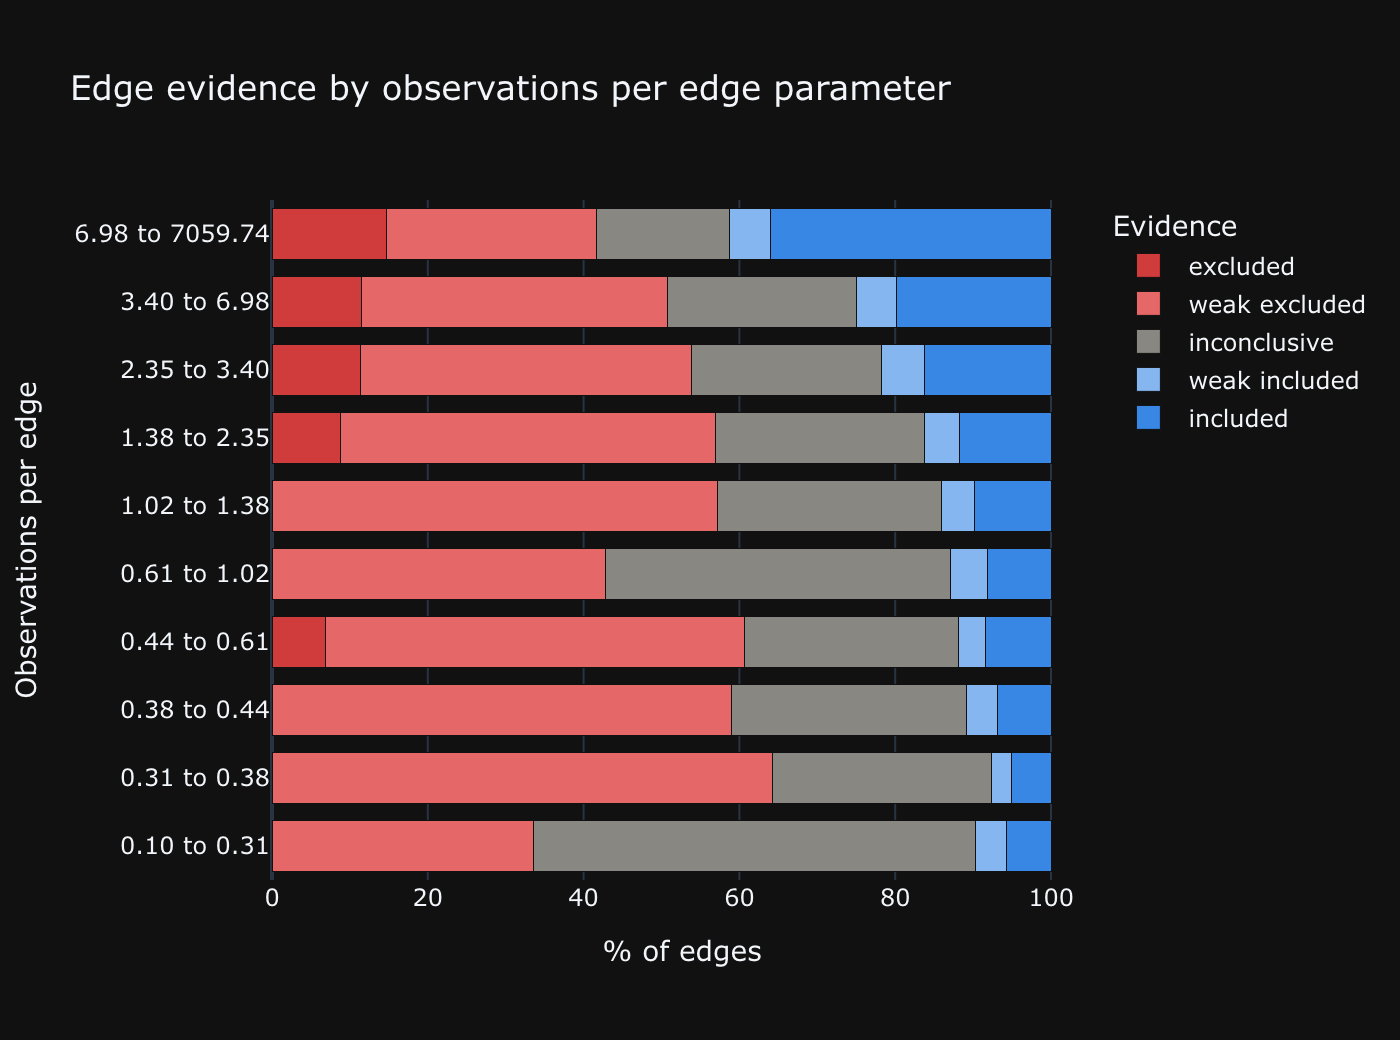

In [10]:
edges["obs_group"] = pd.qcut(edges.obs_per_edge, 10, duplicates="drop")
by_group = (
    edges.groupby(["obs_group", "evidence"], observed=True).size().rename("n").reset_index()
)
by_group["pct"] = (
    by_group.n / by_group.groupby("obs_group", observed=True).n.transform("sum") * 100
)
by_group["band"] = by_group.obs_group.apply(lambda i: f"{i.left:.2f} to {i.right:.2f}")

# plotly sorts these as strings otherwise, which drops "7.00 to 7059.74" in the middle
# of the axis and hides the whole point of the chart
band_order = (
    by_group.drop_duplicates("obs_group")
    .sort_values("obs_group", key=lambda c: [i.left for i in c])
    .band.tolist()
)

print("poorest and richest tenth, % of edges:")
print(
    by_group[by_group.band.isin([band_order[0], band_order[-1]])]
    .pivot(index="evidence", columns="band", values="pct")
    .round(1)
    .to_string()
)

fig = px.bar(
    by_group,
    x="pct",
    y="band",
    color="evidence",
    orientation="h",
    template=TEMPLATE,
    color_discrete_map=EVIDENCE_COLORS,
    category_orders={"evidence": EVIDENCE_ORDER, "band": band_order},
    title="Edge evidence by observations per edge parameter",
    labels={"pct": "% of edges", "band": "Observations per edge", "evidence": "Evidence"},
)
fig.update_layout(
    barmode="stack",
    height=520,
    bargap=0.25,
    yaxis=dict(categoryorder="array", categoryarray=band_order),
)
show(fig, "evidence_by_obs")

# HAHA BAAAABYYYYYY!!!!

Aaaannnnddddd steeper than I expected... The poorest tenth is 56.7% inconclusive while 17.1% in the richest.

So the problem isn't spread evenly over the corpus, it sits in the networks that were too big for the sample they were fitted on. Which networks I pick later is going to matter a lot...